# \ud83c\udf84 Notebook 06: GP-Smoothed Events \u2014 Holiday & Event Effects with Gaussian Processes

**What you will learn:**
- Why binary dummy variables are a poor model for holiday/event effects
- How Gaussian Process smoothing with a Mat\u00e9rn 3/2 kernel creates realistic event shapes
- How to build GP-smoothed event indicators from scratch with NumPy
- Different convolution modes: before (anticipation), after (trailing), overlap (both)
- Hierarchical event weights for sharing information across sparse events
- When to use Fourier seasonality vs. event dummies

**Prerequisites:** Basic understanding of time series and marketing mix models. No PyMC/MCMC needed \u2014 we build everything with NumPy.

---

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import os

# Standard chart style
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC',
    'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#D0D7DE',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#D0D7DE',
})

COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

os.makedirs('images', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. The Problem with Binary Dummies

The simplest way to model a holiday is a binary indicator: 1 on the event week, 0 everywhere else. But real consumer behavior doesn't work like a light switch:

- **Black Friday** \u2014 shoppers start researching deals a week or two before, spending peaks on the day itself, and returns/exchanges trail off over the following weeks.
- **Christmas** \u2014 gift shopping ramps up throughout December, with a sharp drop-off after the 25th.
- **Super Bowl** \u2014 ad buzz builds in the days before the game and sustains for a few days after.

A binary dummy captures none of this ramp-up or tail-off. It assigns the *entire* holiday effect to a single time period, which biases your model's estimates of both the event effect and the media channels that happen to spend heavily around holidays.

Let's visualize the mismatch.

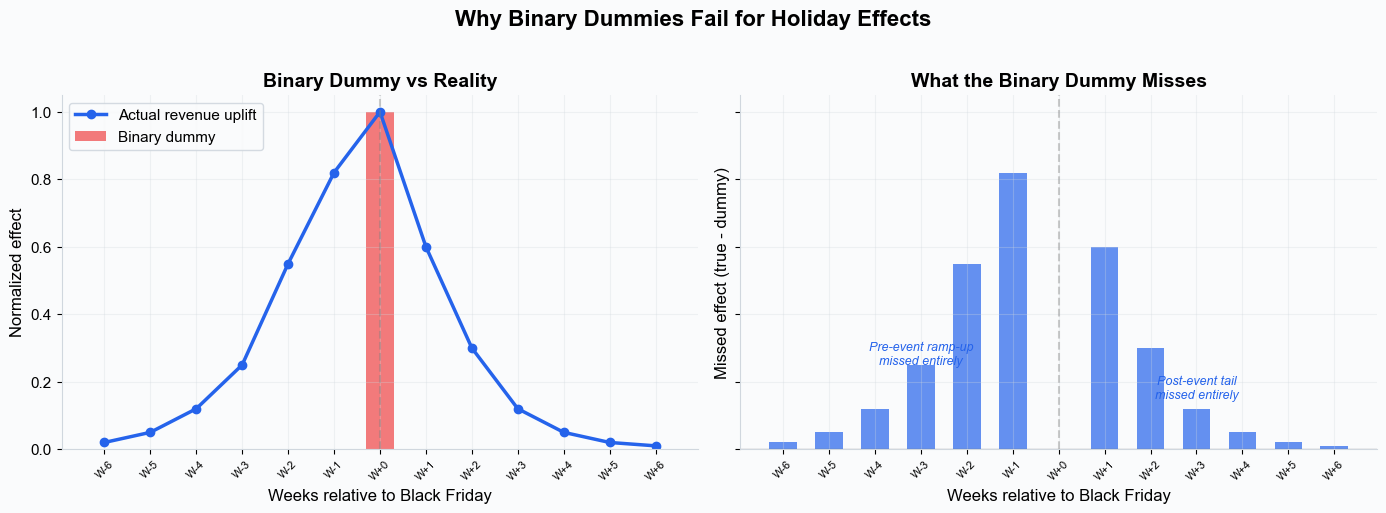

Saved: images/06_binary_vs_reality.png


In [2]:
# Simulate a realistic Black Friday revenue pattern vs binary dummy
weeks = np.arange(-6, 7)  # 6 weeks before, event week, 6 weeks after
labels = [f'W{w:+d}' for w in weeks]

# Binary dummy: 1 only at week 0
binary_dummy = np.where(weeks == 0, 1.0, 0.0)

# Simulated "true" revenue uplift pattern around Black Friday
# Asymmetric: gradual build-up, sharp peak, moderate tail-off
true_effect = np.array([
    0.02, 0.05, 0.12, 0.25, 0.55, 0.82,  # ramp-up
    1.00,                                    # peak (event week)
    0.60, 0.30, 0.12, 0.05, 0.02, 0.01     # tail-off
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: binary dummy
axes[0].bar(weeks, binary_dummy, color=COLORS[3], alpha=0.7, width=0.6, label='Binary dummy')
axes[0].plot(weeks, true_effect, 'o-', color=COLORS[0], lw=2.5, markersize=6, label='Actual revenue uplift')
axes[0].set_title('Binary Dummy vs Reality')
axes[0].set_xlabel('Weeks relative to Black Friday')
axes[0].set_ylabel('Normalized effect')
axes[0].set_xticks(weeks)
axes[0].set_xticklabels(labels, rotation=45, fontsize=8)
axes[0].legend(loc='upper left')
axes[0].axvline(0, color='gray', ls='--', alpha=0.4)

# Right: the residual error
residual = true_effect - binary_dummy
colors_bar = [COLORS[3] if r < 0 else COLORS[0] for r in residual]
axes[1].bar(weeks, residual, color=colors_bar, alpha=0.7, width=0.6)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('What the Binary Dummy Misses')
axes[1].set_xlabel('Weeks relative to Black Friday')
axes[1].set_ylabel('Missed effect (true - dummy)')
axes[1].set_xticks(weeks)
axes[1].set_xticklabels(labels, rotation=45, fontsize=8)
axes[1].axvline(0, color='gray', ls='--', alpha=0.4)

# Add annotation
axes[1].annotate('Pre-event ramp-up\nmissed entirely',
                 xy=(-3, 0.25), fontsize=9, color=COLORS[0],
                 ha='center', fontstyle='italic')
axes[1].annotate('Post-event tail\nmissed entirely',
                 xy=(3, 0.15), fontsize=9, color=COLORS[0],
                 ha='center', fontstyle='italic')

fig.suptitle('Why Binary Dummies Fail for Holiday Effects', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_binary_vs_reality.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_binary_vs_reality.png')

![Binary vs Reality](./images/06_binary_vs_reality.png)

The left panel shows the mismatch: the binary dummy (red bar) captures only the peak week, while the actual revenue uplift (blue line) spreads across many weeks. The right panel shows what the dummy misses \u2014 the entire ramp-up and tail-off pattern ends up as unexplained variance in your model, which gets incorrectly attributed to other variables.

---

## 2. GP Smoothing with the Mat\u00e9rn 3/2 Kernel

The solution is to **convolve** the binary indicator with a smooth kernel function, creating a bell-shaped curve around each event. Production MMM platforms use the **Mat\u00e9rn 3/2 kernel** for this.

### The Mat\u00e9rn 3/2 kernel

$$k(d) = \sigma^2 \left(1 + \frac{\sqrt{3}\,d}{\ell}\right) \exp\left(-\frac{\sqrt{3}\,d}{\ell}\right)$$

Where:
- $d$ = distance (in time periods) from the event
- $\ell$ = **lengthscale** \u2014 controls how wide the smoothing window is
- $\sigma^2$ = variance (we set to 1 for normalization)

The Mat\u00e9rn 3/2 is a good choice because:
- It's **once-differentiable** \u2014 smooth but not *too* smooth (unlike the RBF/squared exponential which is infinitely smooth)
- It has **finite effective range** \u2014 the kernel decays to near-zero much faster than an RBF, so events don't bleed into each other
- It produces **realistic shapes** \u2014 the resulting curves look like actual consumer behavior patterns

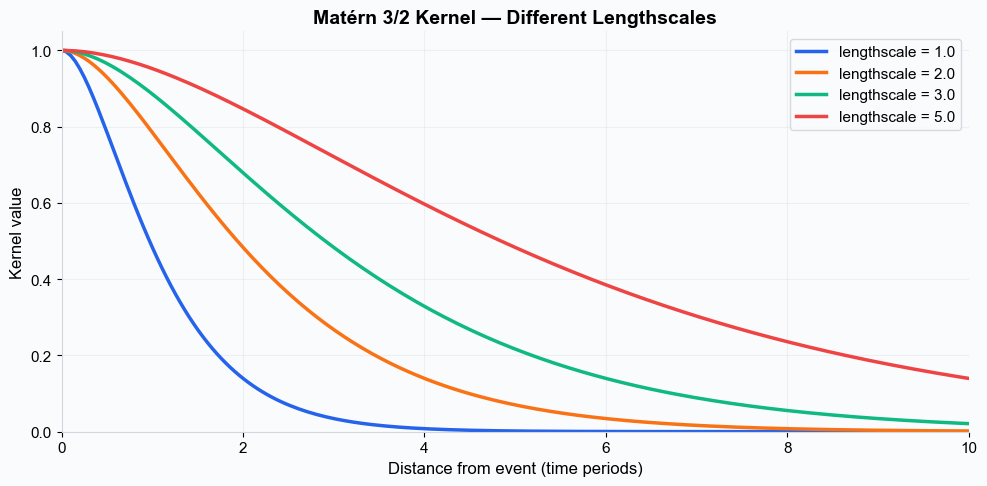

Saved: images/06_matern32_kernel.png


In [3]:
def matern32_kernel(d, lengthscale, sigma2=1.0):
    """Mat\u00e9rn 3/2 kernel function.
    
    k(d) = sigma^2 * (1 + sqrt(3)*d/l) * exp(-sqrt(3)*d/l)
    
    Parameters
    ----------
    d : array-like
        Absolute distance (non-negative)
    lengthscale : float
        Controls the width of the kernel
    sigma2 : float
        Variance (amplitude). Default 1.0
    """
    d = np.abs(d)
    r = np.sqrt(3) * d / lengthscale
    return sigma2 * (1 + r) * np.exp(-r)


# Show the kernel shape for different lengthscales
d = np.linspace(0, 10, 200)

fig, ax = plt.subplots(figsize=(10, 5))
for i, ls in enumerate([1.0, 2.0, 3.0, 5.0]):
    k = matern32_kernel(d, lengthscale=ls)
    ax.plot(d, k, lw=2.5, color=COLORS[i], label=f'lengthscale = {ls}')

ax.set_title('Mat\u00e9rn 3/2 Kernel \u2014 Different Lengthscales')
ax.set_xlabel('Distance from event (time periods)')
ax.set_ylabel('Kernel value')
ax.legend()
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig('images/06_matern32_kernel.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_matern32_kernel.png')

![Mat\u00e9rn 3/2 Kernel](./images/06_matern32_kernel.png)

The lengthscale parameter controls how far the event effect spreads:
- **lengthscale = 1**: Tight, concentrated effect (good for flash sales)
- **lengthscale = 2**: Moderate spread (good for Black Friday)
- **lengthscale = 5**: Wide spread (good for Christmas season)

---

## 3. Building GP-Smoothed Indicators from Scratch

The process is straightforward:

1. Start with a **one-hot indicator** vector: 1 at the event, 0 elsewhere
2. For each time step, compute the Mat\u00e9rn 3/2 kernel distance to the event
3. The kernel values *are* the smoothed indicator
4. Normalize so the peak is 1.0

This is equivalent to convolving the one-hot with the kernel, but computing it directly is simpler.

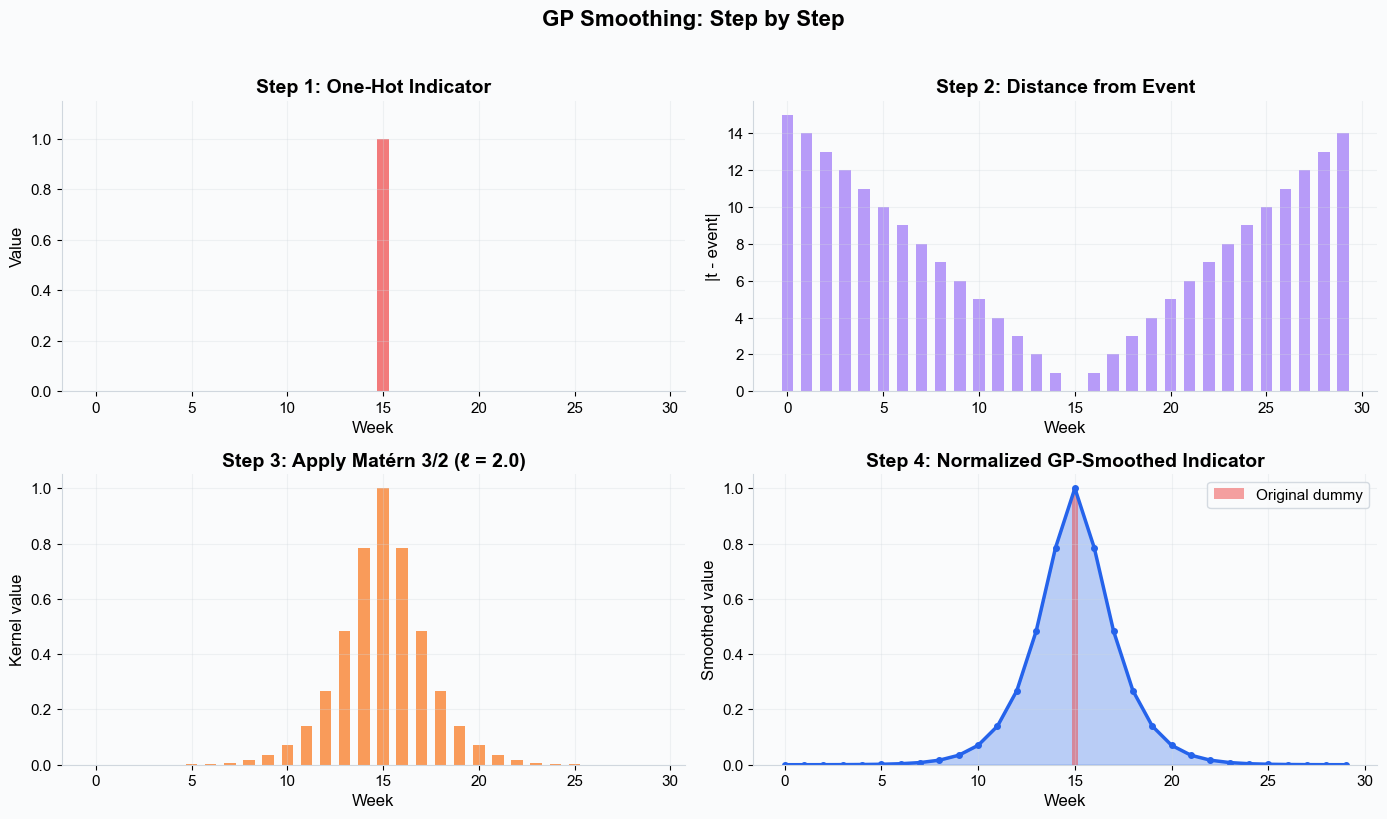

Saved: images/06_gp_smoothing_steps.png


In [4]:
def gp_smooth_event(n_periods, event_index, lengthscale, mode='overlap'):
    """Create a GP-smoothed event indicator.
    
    Parameters
    ----------
    n_periods : int
        Total number of time periods
    event_index : int
        Index of the event period
    lengthscale : float
        Mat\u00e9rn 3/2 lengthscale
    mode : str
        'overlap'  = symmetric smoothing (before + after)
        'before'   = only pre-event buildup (anticipation)
        'after'    = only post-event decay (trailing)
    
    Returns
    -------
    smoothed : np.ndarray of shape (n_periods,)
    """
    t = np.arange(n_periods)
    d = np.abs(t - event_index).astype(float)
    smoothed = matern32_kernel(d, lengthscale)
    
    if mode == 'before':
        # Zero out everything after the event
        smoothed[t > event_index] = 0.0
    elif mode == 'after':
        # Zero out everything before the event
        smoothed[t < event_index] = 0.0
    # 'overlap' keeps both sides
    
    # Normalize peak to 1.0
    if smoothed.max() > 0:
        smoothed = smoothed / smoothed.max()
    return smoothed


# Demonstrate the step-by-step process
n = 30
event_idx = 15
ls = 2.0

# Step 1: One-hot
one_hot = np.zeros(n)
one_hot[event_idx] = 1.0

# Step 2: Compute distances
t = np.arange(n)
distances = np.abs(t - event_idx).astype(float)

# Step 3: Apply kernel
kernel_vals = matern32_kernel(distances, lengthscale=ls)

# Step 4: Normalize
smoothed = kernel_vals / kernel_vals.max()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Step 1
axes[0, 0].bar(t, one_hot, color=COLORS[3], alpha=0.7, width=0.6)
axes[0, 0].set_title('Step 1: One-Hot Indicator')
axes[0, 0].set_xlabel('Week')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_ylim(0, 1.15)

# Step 2
axes[0, 1].bar(t, distances, color=COLORS[4], alpha=0.6, width=0.6)
axes[0, 1].set_title('Step 2: Distance from Event')
axes[0, 1].set_xlabel('Week')
axes[0, 1].set_ylabel('|t - event|')

# Step 3
axes[1, 0].bar(t, kernel_vals, color=COLORS[1], alpha=0.7, width=0.6)
axes[1, 0].set_title(f'Step 3: Apply Mat\u00e9rn 3/2 (\u2113 = {ls})')
axes[1, 0].set_xlabel('Week')
axes[1, 0].set_ylabel('Kernel value')

# Step 4
axes[1, 1].fill_between(t, 0, smoothed, color=COLORS[0], alpha=0.3)
axes[1, 1].plot(t, smoothed, 'o-', color=COLORS[0], lw=2.5, markersize=4)
axes[1, 1].bar(t, one_hot, color=COLORS[3], alpha=0.5, width=0.3, label='Original dummy')
axes[1, 1].set_title('Step 4: Normalized GP-Smoothed Indicator')
axes[1, 1].set_xlabel('Week')
axes[1, 1].set_ylabel('Smoothed value')
axes[1, 1].legend(loc='upper right')

fig.suptitle('GP Smoothing: Step by Step', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_gp_smoothing_steps.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_gp_smoothing_steps.png')

![GP Smoothing Steps](./images/06_gp_smoothing_steps.png)

The process converts a single spike into a smooth bell curve that captures the gradual build-up and decay of event effects. The resulting indicator can be used directly as a regressor in your model.

---

## 4. Before/After Comparison: Black Friday & Christmas

Let's compare binary dummies with GP-smoothed versions for two major retail events.

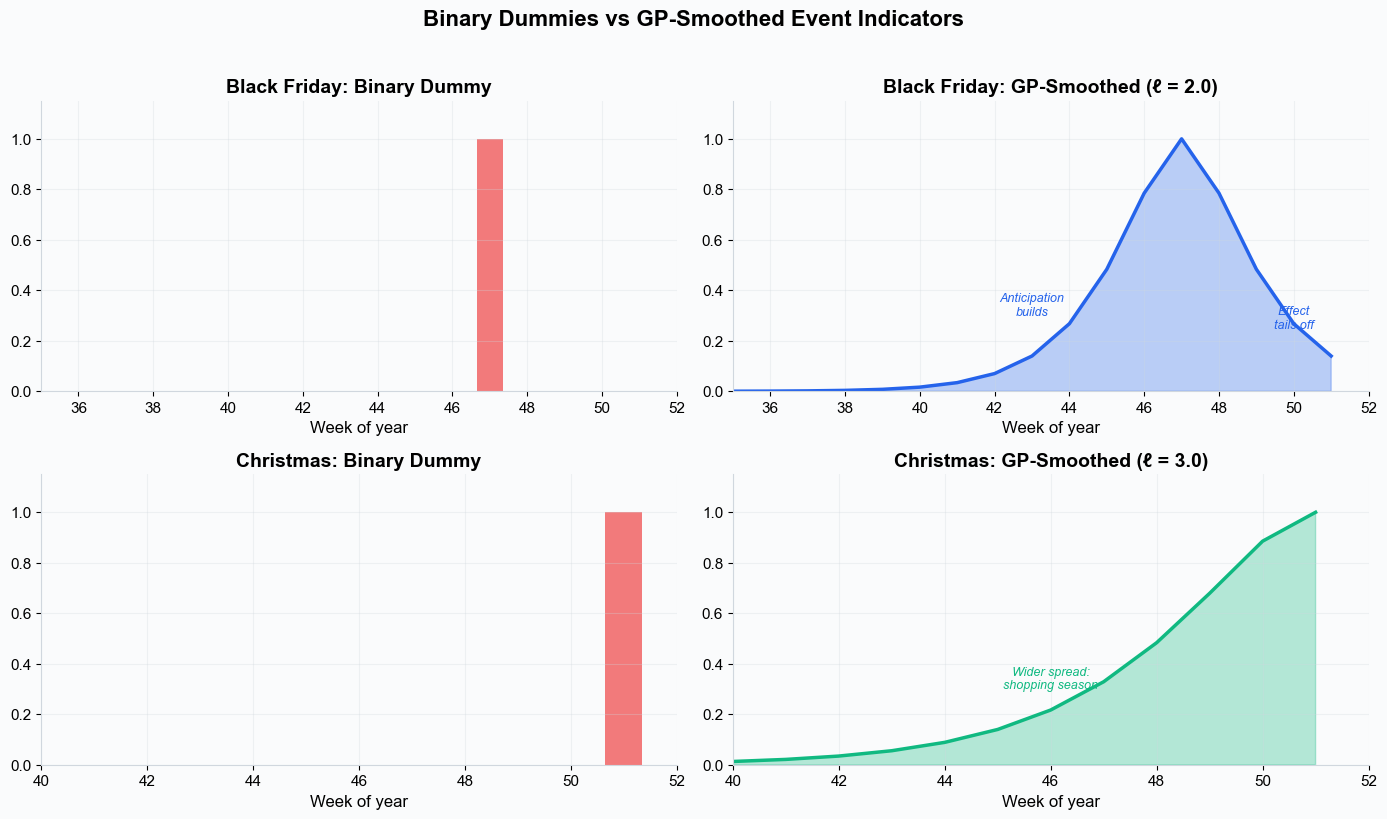

Saved: images/06_before_after_comparison.png


In [5]:
n = 52  # one year of weekly data
bf_idx = 47   # Black Friday ~ late November (week 47)
xmas_idx = 51 # Christmas ~ late December (week 51)

# Binary dummies
bf_binary = np.zeros(n)
bf_binary[bf_idx] = 1.0

xmas_binary = np.zeros(n)
xmas_binary[xmas_idx] = 1.0

# GP-smoothed versions
bf_smoothed = gp_smooth_event(n, bf_idx, lengthscale=2.0, mode='overlap')
xmas_smoothed = gp_smooth_event(n, xmas_idx, lengthscale=3.0, mode='overlap')

t = np.arange(n)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Black Friday binary
axes[0, 0].bar(t, bf_binary, color=COLORS[3], alpha=0.7, width=0.7)
axes[0, 0].set_title('Black Friday: Binary Dummy')
axes[0, 0].set_xlabel('Week of year')
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_xlim(35, 52)

# Black Friday smoothed
axes[0, 1].fill_between(t, 0, bf_smoothed, color=COLORS[0], alpha=0.3)
axes[0, 1].plot(t, bf_smoothed, '-', color=COLORS[0], lw=2.5)
axes[0, 1].set_title(f'Black Friday: GP-Smoothed (\u2113 = 2.0)')
axes[0, 1].set_xlabel('Week of year')
axes[0, 1].set_ylim(0, 1.15)
axes[0, 1].set_xlim(35, 52)
axes[0, 1].annotate('Anticipation\nbuilds', xy=(43, 0.3), fontsize=9,
                     color=COLORS[0], ha='center', fontstyle='italic')
axes[0, 1].annotate('Effect\ntails off', xy=(50, 0.25), fontsize=9,
                     color=COLORS[0], ha='center', fontstyle='italic')

# Christmas binary
axes[1, 0].bar(t, xmas_binary, color=COLORS[3], alpha=0.7, width=0.7)
axes[1, 0].set_title('Christmas: Binary Dummy')
axes[1, 0].set_xlabel('Week of year')
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].set_xlim(40, 52)

# Christmas smoothed
axes[1, 1].fill_between(t, 0, xmas_smoothed, color=COLORS[2], alpha=0.3)
axes[1, 1].plot(t, xmas_smoothed, '-', color=COLORS[2], lw=2.5)
axes[1, 1].set_title(f'Christmas: GP-Smoothed (\u2113 = 3.0)')
axes[1, 1].set_xlabel('Week of year')
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].set_xlim(40, 52)
axes[1, 1].annotate('Wider spread:\nshopping season', xy=(46, 0.3), fontsize=9,
                     color=COLORS[2], ha='center', fontstyle='italic')

fig.suptitle('Binary Dummies vs GP-Smoothed Event Indicators', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_before_after_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_before_after_comparison.png')

![Before/After Comparison](./images/06_before_after_comparison.png)

Notice the different lengthscales: Black Friday gets a tighter kernel (\u2113=2) because the effect is concentrated around a single weekend, while Christmas gets a wider kernel (\u2113=3) to capture the extended shopping season.

---

## 5. Convolution Modes

Not all events have symmetric effects. Some events primarily create **anticipation** (pre-event excitement), others have **trailing effects** (post-event returns, word-of-mouth), and some have both.

| Mode | When to use | Example |
|------|------------|--------|
| **Before** (anticipation) | Consumers act *before* the event | Product launch hype, countdown sales |
| **After** (trailing) | Impact persists *after* the event | Super Bowl ad recall, post-holiday returns |
| **Overlap** (both) | Effect spans both sides | Black Friday, Christmas, back-to-school |

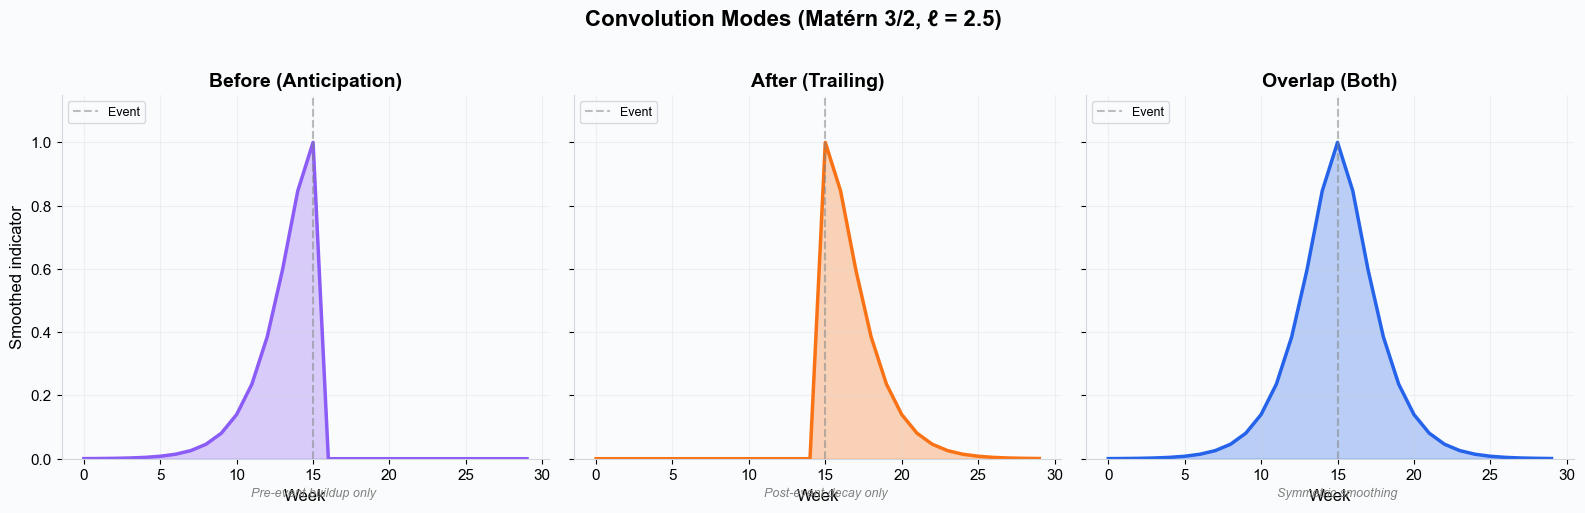

Saved: images/06_convolution_modes.png


In [6]:
n = 30
ev = 15
ls = 2.5

before = gp_smooth_event(n, ev, ls, mode='before')
after = gp_smooth_event(n, ev, ls, mode='after')
overlap = gp_smooth_event(n, ev, ls, mode='overlap')

t = np.arange(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, data, title, color, desc in [
    (axes[0], before, 'Before (Anticipation)', COLORS[4], 'Pre-event buildup only'),
    (axes[1], after, 'After (Trailing)', COLORS[1], 'Post-event decay only'),
    (axes[2], overlap, 'Overlap (Both)', COLORS[0], 'Symmetric smoothing'),
]:
    ax.fill_between(t, 0, data, color=color, alpha=0.3)
    ax.plot(t, data, '-', color=color, lw=2.5)
    ax.axvline(ev, color='gray', ls='--', alpha=0.5, label='Event')
    ax.set_title(title)
    ax.set_xlabel('Week')
    ax.set_ylim(0, 1.15)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(ev, -0.12, desc, ha='center', fontsize=9, fontstyle='italic', color='gray')

axes[0].set_ylabel('Smoothed indicator')

fig.suptitle(f'Convolution Modes (Mat\u00e9rn 3/2, \u2113 = {ls})', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_convolution_modes.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_convolution_modes.png')

![Convolution Modes](./images/06_convolution_modes.png)

The mode you choose depends on the event type. For most retail holidays, **overlap** (symmetric) is the default. For product launches where the hype is before the event, use **before**. For events like the Super Bowl where ad impact trails afterward, use **after**.

---

## 6. Hierarchical Event Weights

Most MMM datasets have very few events \u2014 maybe 2 Black Fridays and 2 Christmases in a 2-year dataset. With so few observations, estimating a separate coefficient for each event type is noisy.

The solution is **hierarchical Normal weights**: instead of independent coefficients, event weights are drawn from a shared distribution:

$$w_e \sim \text{Normal}(\mu_{\text{events}},\, \sigma_{\text{events}})$$

Where $\mu_{\text{events}}$ and $\sigma_{\text{events}}$ are themselves estimated from the data.

This means:
- If you have **many events**, each weight can deviate freely from the group mean
- If you have **few events**, the weights are regularized toward the group mean (shrinkage)
- Events that are truly different (e.g., Black Friday vs. a minor holiday) will still get distinct weights \u2014 the data just needs to be strong enough to justify the difference

Let's visualize how hierarchical pooling helps with sparse events.

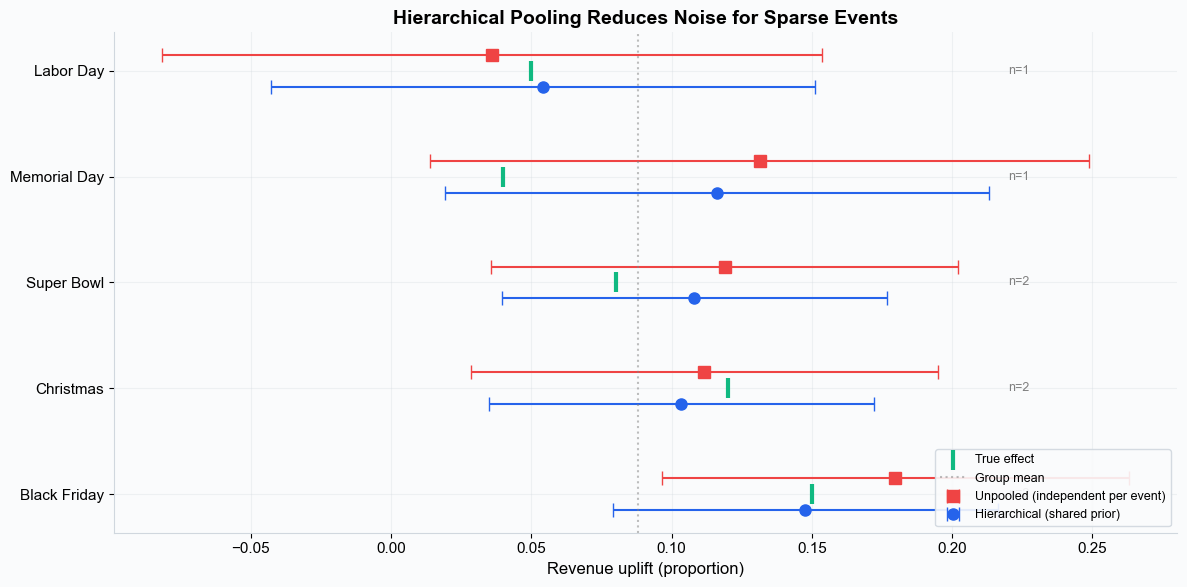

Saved: images/06_hierarchical_weights.png


In [7]:
# Simulate: 5 events, only 1-2 observations each
np.random.seed(42)

event_names = ['Black Friday', 'Christmas', 'Super Bowl', 'Memorial Day', 'Labor Day']
true_effects = [0.15, 0.12, 0.08, 0.04, 0.05]  # True revenue uplift
n_obs = [2, 2, 2, 1, 1]  # Number of times each event occurred in dataset

# Unpooled estimates (noisy due to few observations)
unpooled = [te + np.random.normal(0, 0.06) for te in true_effects]
unpooled_se = [0.06 / np.sqrt(n) for n in n_obs]

# Hierarchical estimate: shrink toward group mean
group_mean = np.mean(true_effects)
shrinkage = 0.35  # how much to shrink toward mean (higher = more shrinkage)
hierarchical = [(1 - shrinkage) * up + shrinkage * group_mean for up in unpooled]
hierarchical_se = [se * (1 - shrinkage * 0.5) for se in unpooled_se]

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(event_names))

# Unpooled
ax.errorbar(unpooled, y_pos + 0.15, xerr=[se * 1.96 for se in unpooled_se],
            fmt='s', color=COLORS[3], markersize=8, capsize=5, lw=1.5,
            label='Unpooled (independent per event)')

# Hierarchical
ax.errorbar(hierarchical, y_pos - 0.15, xerr=[se * 1.96 for se in hierarchical_se],
            fmt='o', color=COLORS[0], markersize=8, capsize=5, lw=1.5,
            label='Hierarchical (shared prior)')

# True values
ax.scatter(true_effects, y_pos, marker='|', color=COLORS[2], s=200, lw=3,
           zorder=5, label='True effect')

# Group mean
ax.axvline(group_mean, color='gray', ls=':', alpha=0.5, label='Group mean')

ax.set_yticks(y_pos)
ax.set_yticklabels(event_names)
ax.set_xlabel('Revenue uplift (proportion)')
ax.set_title('Hierarchical Pooling Reduces Noise for Sparse Events')
ax.legend(loc='lower right', fontsize=9)

# Annotations for n_obs
for i, (name, nob) in enumerate(zip(event_names, n_obs)):
    ax.text(0.22, i, f'n={nob}', fontsize=9, color='gray', va='center')

fig.tight_layout()
fig.savefig('images/06_hierarchical_weights.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_hierarchical_weights.png')

![Hierarchical Weights](./images/06_hierarchical_weights.png)

The hierarchical estimates (blue circles) are **closer to the true effects** (green ticks) than the unpooled estimates (red squares). Events with fewer observations (Memorial Day, Labor Day with n=1) benefit the most from pooling \u2014 they borrow strength from the group.

---

## 7. Seasonality vs Events: When to Use Which

A common question: should you model Christmas as a **seasonal effect** (Fourier terms) or an **event effect** (GP-smoothed indicator)?

The answer depends on the pattern:

| Characteristic | Fourier Seasonality | GP-Smoothed Events |
|---|---|---|
| Pattern | Smooth, repeating cycle | Sharp, isolated spikes |
| Frequency | Happens every year/month/week | Happens 1-2 times/year |
| Shape | Sinusoidal | Asymmetric, peaked |
| Examples | Summer uplift, Monday dip | Black Friday, Super Bowl |
| Date fixed? | Yes (same month each year) | Sometimes (Easter moves) |

**Rule of thumb:** If the effect is smooth and spans multiple months, use seasonality. If it's a sharp spike around a specific date, use an event dummy.

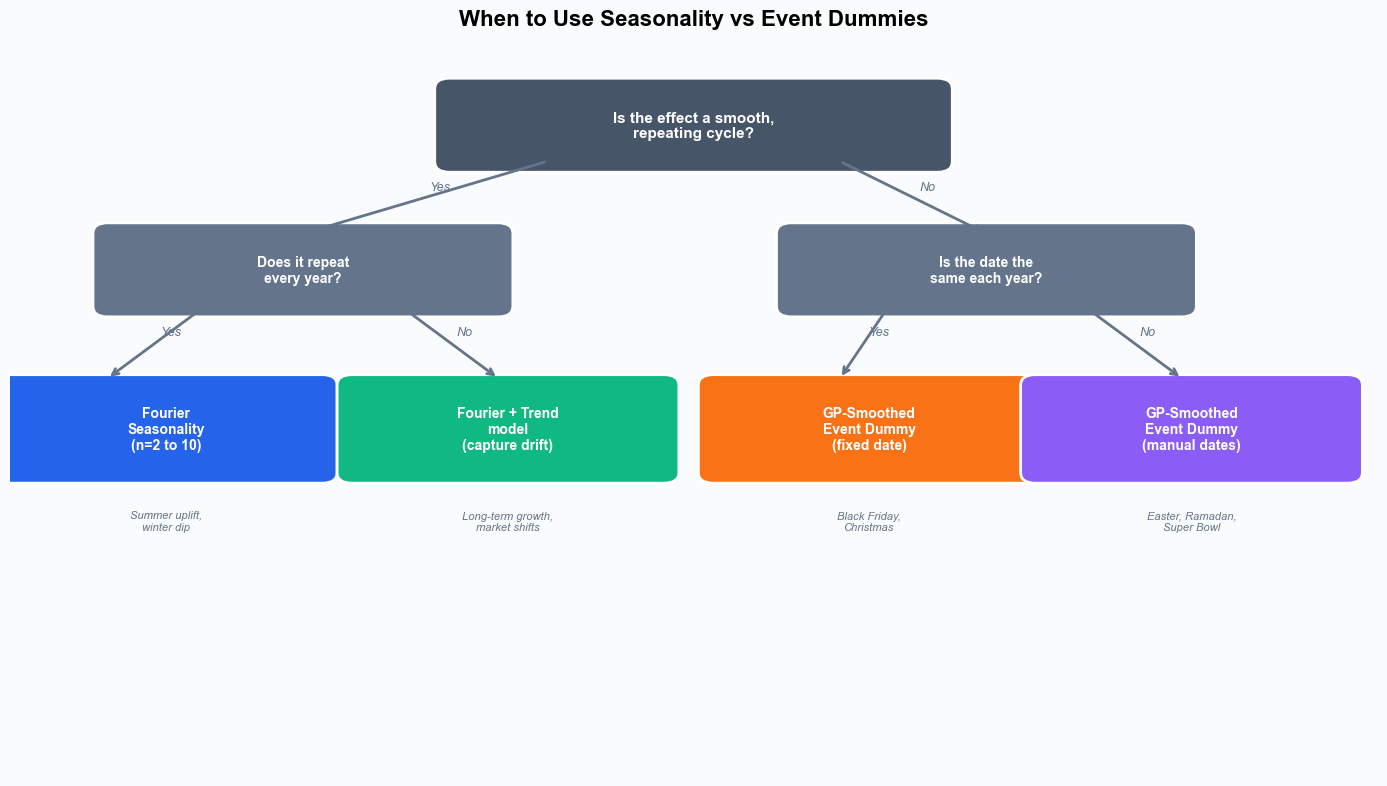

Saved: images/06_seasonality_vs_events.png


In [8]:
# Decision tree: Seasonality vs Events
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#FAFBFC')
fig.patch.set_facecolor('#FAFBFC')

def draw_box(ax, x, y, w, h, text, color, fontsize=10, textcolor='white'):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle='round,pad=0.15',
                         facecolor=color, edgecolor='white', lw=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=textcolor,
            wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#64748B', lw=2))
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.15, my + 0.1, label, fontsize=9, color='#64748B',
                fontstyle='italic', ha='center')

# Root question
draw_box(ax, 4.5, 8.5, 5, 1.0, 'Is the effect a smooth,\nrepeating cycle?', '#475569', fontsize=11)

# Yes branch: Fourier
draw_arrow(ax, 5.5, 8.5, 3, 7.5, 'Yes')
draw_box(ax, 1, 6.5, 4, 1.0, 'Does it repeat\nevery year?', '#64748B', fontsize=10)

draw_arrow(ax, 2, 6.5, 1.0, 5.5, 'Yes')
draw_box(ax, 0, 4.2, 3.2, 1.2, 'Fourier\nSeasonality\n(n=2 to 10)', COLORS[0], fontsize=10)
ax.text(1.6, 3.4, 'Summer uplift,\nwinter dip', fontsize=8, ha='center',
        color='#64748B', fontstyle='italic')

draw_arrow(ax, 4, 6.5, 5, 5.5, 'No')
draw_box(ax, 3.5, 4.2, 3.2, 1.2, 'Fourier + Trend\nmodel\n(capture drift)', COLORS[2], fontsize=10)
ax.text(5.1, 3.4, 'Long-term growth,\nmarket shifts', fontsize=8, ha='center',
        color='#64748B', fontstyle='italic')

# No branch: Events
draw_arrow(ax, 8.5, 8.5, 10, 7.5, 'No')
draw_box(ax, 8, 6.5, 4, 1.0, 'Is the date the\nsame each year?', '#64748B', fontsize=10)

draw_arrow(ax, 9, 6.5, 8.5, 5.5, 'Yes')
draw_box(ax, 7.2, 4.2, 3.2, 1.2, 'GP-Smoothed\nEvent Dummy\n(fixed date)', COLORS[1], fontsize=10)
ax.text(8.8, 3.4, 'Black Friday,\nChristmas', fontsize=8, ha='center',
        color='#64748B', fontstyle='italic')

draw_arrow(ax, 11, 6.5, 12, 5.5, 'No')
draw_box(ax, 10.5, 4.2, 3.2, 1.2, 'GP-Smoothed\nEvent Dummy\n(manual dates)', COLORS[4], fontsize=10)
ax.text(12.1, 3.4, 'Easter, Ramadan,\nSuper Bowl', fontsize=8, ha='center',
        color='#64748B', fontstyle='italic')

ax.set_title('When to Use Seasonality vs Event Dummies', fontsize=16, fontweight='bold', pad=20)

fig.tight_layout()
fig.savefig('images/06_seasonality_vs_events.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_seasonality_vs_events.png')

![Seasonality vs Events](./images/06_seasonality_vs_events.png)

In practice, most MMMs use **both**: Fourier terms capture the broad seasonal pattern (summer vs. winter), while GP-smoothed event dummies capture sharp holiday spikes that sit on top of the seasonal curve.

---

## 8. Multiple Events with Overlapping Effects

When events are close together (like Black Friday and Christmas), their GP-smoothed indicators can overlap. This is actually a feature, not a bug \u2014 the model can separately estimate each event's contribution even when they blend together.

Let's build smoothed indicators for multiple events and see how they combine.

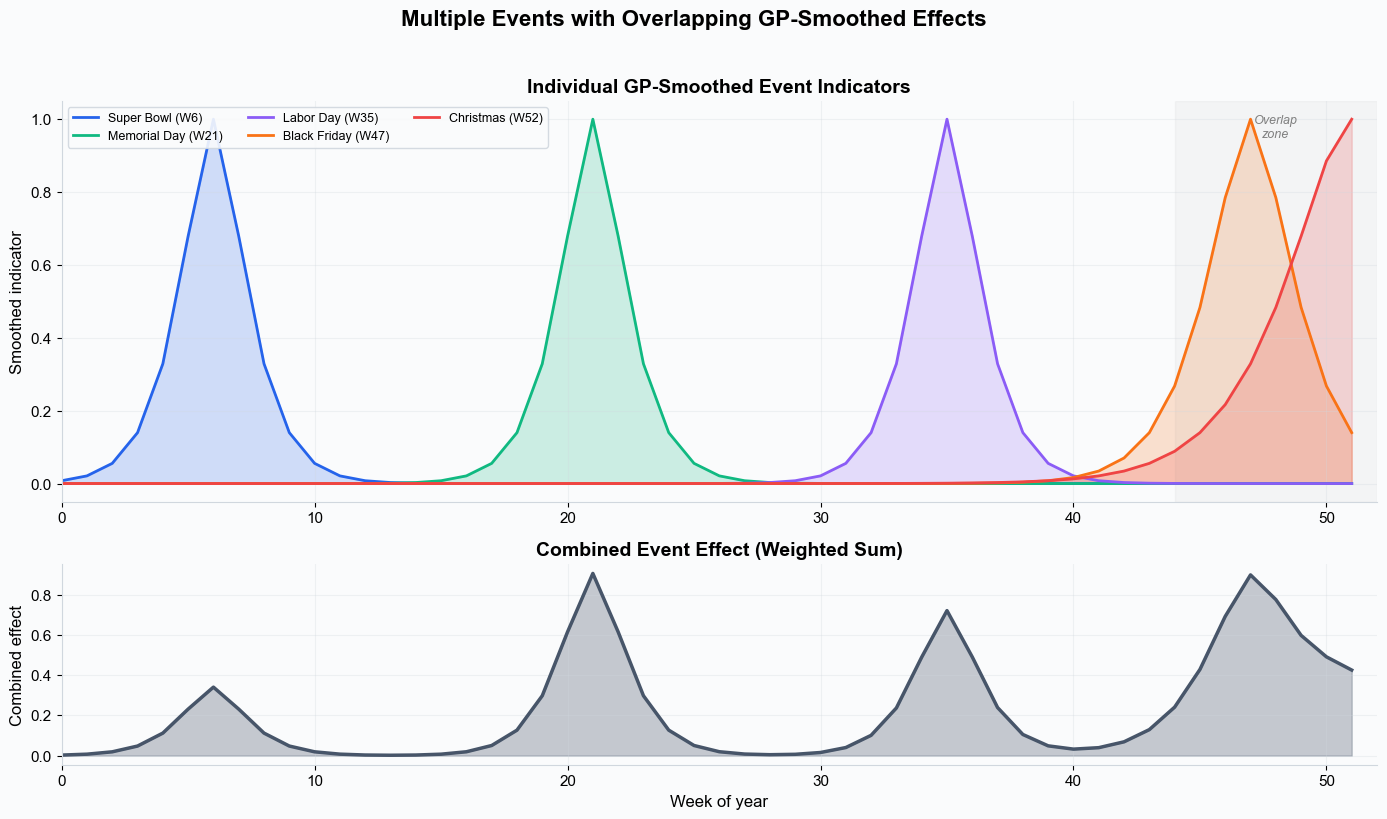

Saved: images/06_multiple_events.png


In [9]:
n = 52
events = {
    'Super Bowl (W6)': (6, 1.5, COLORS[0]),
    'Memorial Day (W21)': (21, 1.5, COLORS[2]),
    'Labor Day (W35)': (35, 1.5, COLORS[4]),
    'Black Friday (W47)': (47, 2.0, COLORS[1]),
    'Christmas (W52)': (51, 3.0, COLORS[3]),
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

t = np.arange(n)
combined = np.zeros(n)

for name, (idx, ls, color) in events.items():
    smoothed = gp_smooth_event(n, idx, ls, mode='overlap')
    axes[0].fill_between(t, 0, smoothed, alpha=0.2, color=color)
    axes[0].plot(t, smoothed, '-', lw=2, color=color, label=name)
    combined += smoothed * np.random.uniform(0.3, 1.0)  # Simulated weights

axes[0].set_title('Individual GP-Smoothed Event Indicators')
axes[0].set_ylabel('Smoothed indicator')
axes[0].legend(loc='upper left', fontsize=9, ncol=3)
axes[0].set_xlim(0, 52)

# Combined effect
axes[1].fill_between(t, 0, combined, alpha=0.3, color='#475569')
axes[1].plot(t, combined, '-', lw=2.5, color='#475569')
axes[1].set_title('Combined Event Effect (Weighted Sum)')
axes[1].set_xlabel('Week of year')
axes[1].set_ylabel('Combined effect')
axes[1].set_xlim(0, 52)

# Highlight overlap zone
axes[0].axvspan(44, 52, alpha=0.05, color='gray')
axes[0].text(48, 0.95, 'Overlap\nzone', fontsize=9, ha='center',
             color='gray', fontstyle='italic')

fig.suptitle('Multiple Events with Overlapping GP-Smoothed Effects', fontsize=16,
             fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_multiple_events.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_multiple_events.png')

![Multiple Events](./images/06_multiple_events.png)

The top panel shows each event's individual GP-smoothed indicator. The bottom panel shows their weighted sum \u2014 the total event effect that gets added to the model. Notice how Black Friday and Christmas overlap in weeks 47-52, creating a compound holiday season effect.

---

## 9. Applying to Real Data

Let's load the sample weekly MMM dataset and create GP-smoothed event indicators for Black Friday and Christmas. We'll then compare them against actual revenue patterns.

In [10]:
# Load sample data
df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])
print(f'Data: {len(df)} weeks, {df.date.min().date()} to {df.date.max().date()}')
print(f'Black Friday weeks: {df[df.black_friday == 1].date.dt.date.tolist()}')
print(f'Christmas weeks: {df[df.christmas == 1].date.dt.date.tolist()}')
df.head()

Data: 104 weeks, 2023-01-02 to 2024-12-23
Black Friday weeks: [datetime.date(2023, 11, 27), datetime.date(2023, 12, 25), datetime.date(2024, 11, 25), datetime.date(2024, 12, 23)]
Christmas weeks: [datetime.date(2023, 12, 25), datetime.date(2024, 12, 23)]


,date,revenue,tv_spend,facebook_spend,google_search_spend,radio_spend,print_spend,competitor_spend,temperature,black_friday,christmas
0,2023-01-02,415347.38,44297.59,12324.66,21047.02,0.00,8829.08,19018.51,5.5,0,0
1,2023-01-09,448657.78,34361.58,16350.69,57286.45,8007.27,0.00,30129.15,7.4,0,0
2,2023-01-16,446594.40,47055.14,34306.60,21402.59,10756.73,0.00,27026.35,7.1,0,0
3,2023-01-23,451778.48,66783.54,14578.29,25353.44,4977.10,3125.23,38330.92,4.8,0,0
4,2023-01-30,451489.81,33068.57,15195.81,24009.40,0.00,0.00,26243.63,9.1,0,0


In [11]:
# Create GP-smoothed versions of the event indicators
n = len(df)

def smooth_event_column(indicator_series, lengthscale, mode='overlap'):
    """Smooth a binary indicator column using GP convolution.
    
    Handles multiple events (e.g., 2 Black Fridays in a 2-year dataset)
    by smoothing each occurrence and taking the element-wise maximum.
    """
    event_indices = np.where(indicator_series.values == 1)[0]
    result = np.zeros(n)
    
    for idx in event_indices:
        smoothed = gp_smooth_event(n, idx, lengthscale, mode=mode)
        result = np.maximum(result, smoothed)  # Take max to avoid double-counting overlaps
    
    return result

df['bf_smoothed'] = smooth_event_column(df['black_friday'], lengthscale=2.0)
df['xmas_smoothed'] = smooth_event_column(df['christmas'], lengthscale=3.0)

print('GP-smoothed columns created.')
print(f'Black Friday smoothed: non-zero in {(df.bf_smoothed > 0.01).sum()} of {n} weeks')
print(f'Christmas smoothed: non-zero in {(df.xmas_smoothed > 0.01).sum()} of {n} weeks')

GP-smoothed columns created.
Black Friday smoothed: non-zero in 31 of 104 weeks
Christmas smoothed: non-zero in 35 of 104 weeks


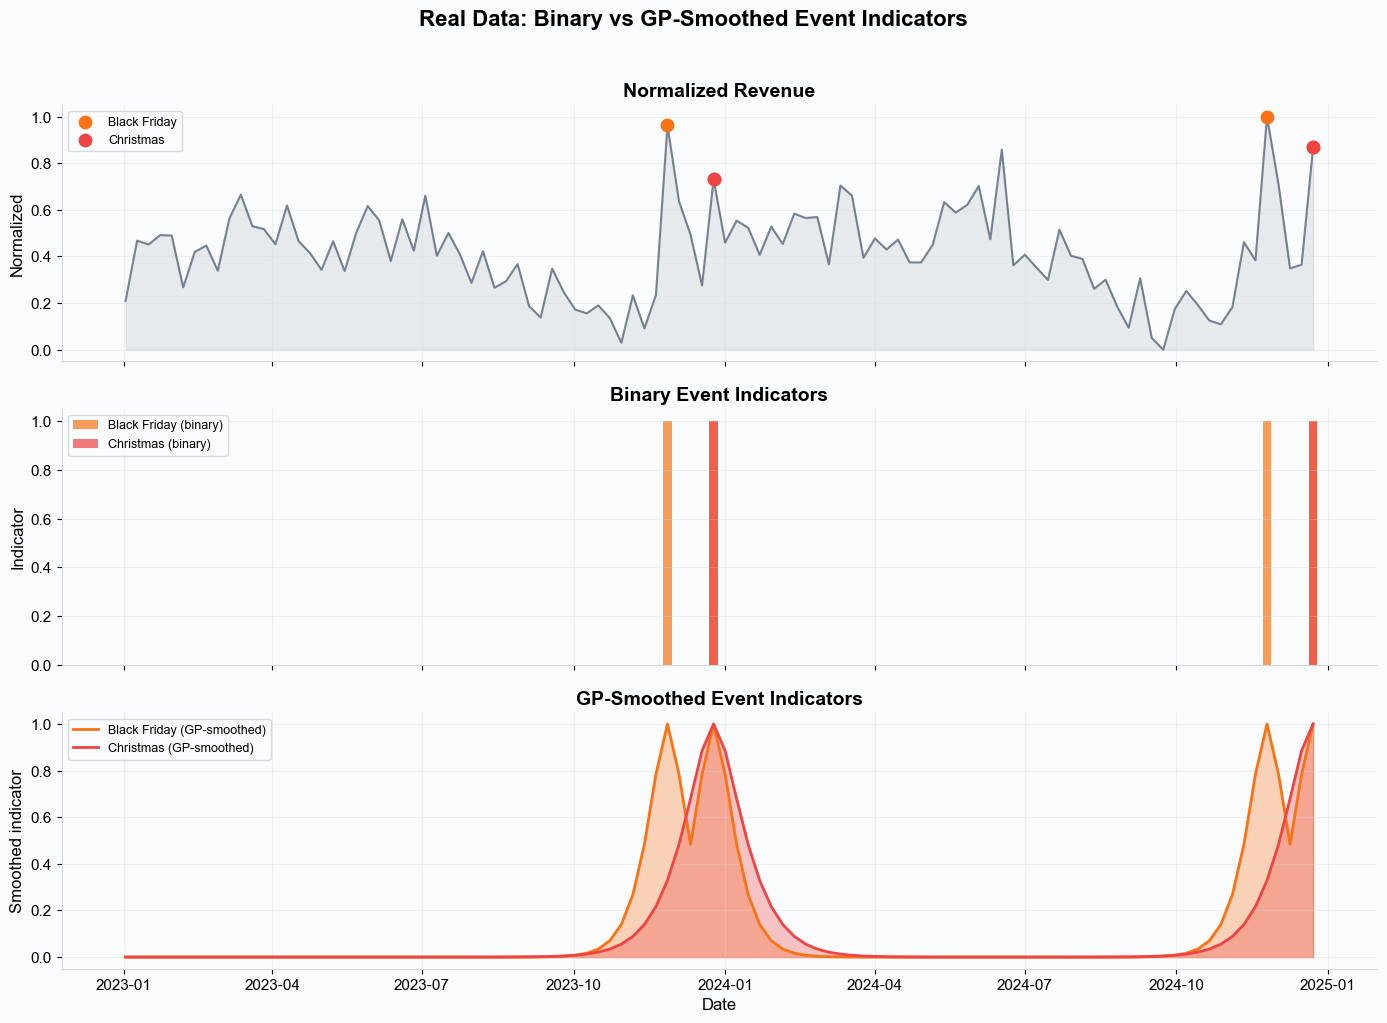

Saved: images/06_real_data_events.png


In [12]:
# Normalize revenue for visual comparison
rev_norm = (df['revenue'] - df['revenue'].min()) / (df['revenue'].max() - df['revenue'].min())

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Revenue
axes[0].plot(df['date'], rev_norm, '-', color='#475569', lw=1.5, alpha=0.7)
axes[0].fill_between(df['date'], 0, rev_norm, alpha=0.1, color='#475569')
axes[0].set_title('Normalized Revenue')
axes[0].set_ylabel('Normalized')

# Highlight event weeks on revenue
bf_weeks = df[df.black_friday == 1]
xmas_weeks = df[df.christmas == 1]
axes[0].scatter(bf_weeks['date'],
                (bf_weeks['revenue'] - df['revenue'].min()) / (df['revenue'].max() - df['revenue'].min()),
                color=COLORS[1], s=80, zorder=5, label='Black Friday')
axes[0].scatter(xmas_weeks['date'],
                (xmas_weeks['revenue'] - df['revenue'].min()) / (df['revenue'].max() - df['revenue'].min()),
                color=COLORS[3], s=80, zorder=5, label='Christmas')
axes[0].legend(loc='upper left', fontsize=9)

# Binary dummies
axes[1].bar(df['date'], df['black_friday'], width=5, color=COLORS[1], alpha=0.7, label='Black Friday (binary)')
axes[1].bar(df['date'], df['christmas'], width=5, color=COLORS[3], alpha=0.7, label='Christmas (binary)')
axes[1].set_title('Binary Event Indicators')
axes[1].set_ylabel('Indicator')
axes[1].legend(loc='upper left', fontsize=9)

# GP-smoothed
axes[2].fill_between(df['date'], 0, df['bf_smoothed'], alpha=0.3, color=COLORS[1])
axes[2].plot(df['date'], df['bf_smoothed'], '-', color=COLORS[1], lw=2, label='Black Friday (GP-smoothed)')
axes[2].fill_between(df['date'], 0, df['xmas_smoothed'], alpha=0.3, color=COLORS[3])
axes[2].plot(df['date'], df['xmas_smoothed'], '-', color=COLORS[3], lw=2, label='Christmas (GP-smoothed)')
axes[2].set_title('GP-Smoothed Event Indicators')
axes[2].set_ylabel('Smoothed indicator')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left', fontsize=9)

fig.suptitle('Real Data: Binary vs GP-Smoothed Event Indicators',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('images/06_real_data_events.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_real_data_events.png')

![Real Data Events](./images/06_real_data_events.png)

The bottom panel shows how GP-smoothed indicators create realistic, gradual event effects that better align with the actual revenue patterns in the top panel. The binary dummies in the middle panel only capture a single week per event.

---

## 10. Lengthscale Sensitivity

The lengthscale is the most important hyperparameter. Let's see how it affects the smoothed indicator for our real data.

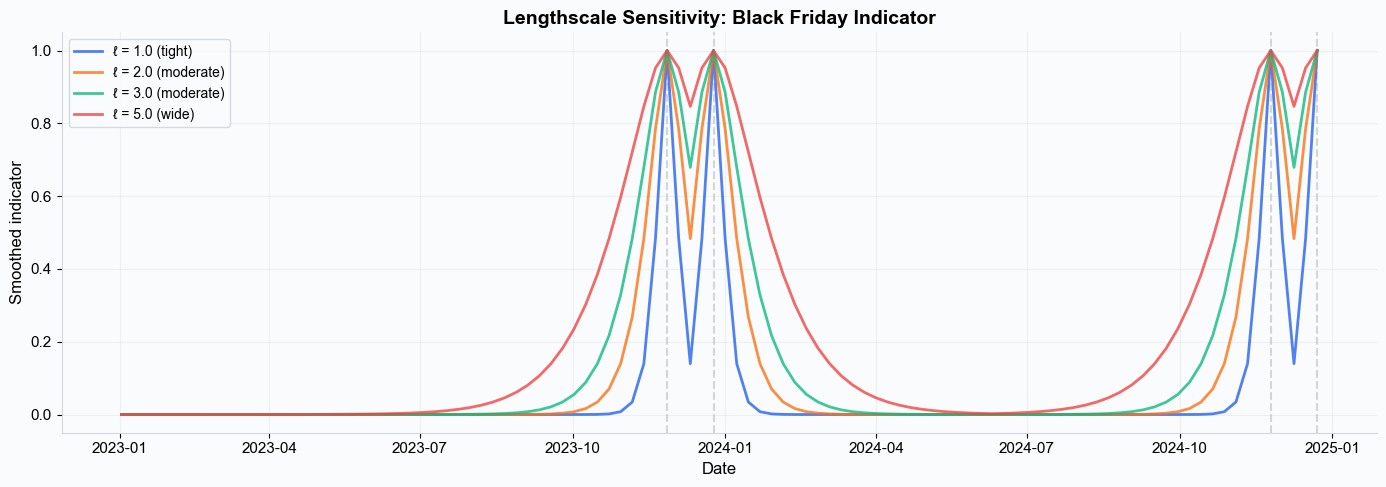

Saved: images/06_lengthscale_sensitivity.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

lengthscales = [1.0, 2.0, 3.0, 5.0]
for i, ls in enumerate(lengthscales):
    smoothed = smooth_event_column(df['black_friday'], lengthscale=ls)
    ax.plot(df['date'], smoothed, '-', color=COLORS[i], lw=2,
            label=f'\u2113 = {ls} ({"tight" if ls <= 1.5 else "moderate" if ls <= 3 else "wide"})',
            alpha=0.8)

# Mark actual Black Friday dates
for _, row in bf_weeks.iterrows():
    ax.axvline(row['date'], color='gray', ls='--', alpha=0.3)

ax.set_title('Lengthscale Sensitivity: Black Friday Indicator')
ax.set_xlabel('Date')
ax.set_ylabel('Smoothed indicator')
ax.legend(loc='upper left', fontsize=10)

fig.tight_layout()
fig.savefig('images/06_lengthscale_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: images/06_lengthscale_sensitivity.png')

![Lengthscale Sensitivity](./images/06_lengthscale_sensitivity.png)

**Practical guidance for choosing lengthscale:**

| Lengthscale | Effect spread | Good for |
|---|---|---|
| 1.0 | Very concentrated | Flash sales, one-day events |
| 1.5\u20132.0 | Moderate spread | Black Friday, Super Bowl |
| 3.0\u20134.0 | Wide spread | Christmas, back-to-school |
| 5.0+ | Very wide | Entire holiday "season" effects |

In a Bayesian MMM, the lengthscale can be estimated from data rather than fixed. But starting with a reasonable value (1.5\u20133.0 for weekly data) is a good default.

---

---

## Using GP-Smoothed Events with PyMC-Marketing

[PyMC-Marketing](https://github.com/pymc-labs/pymc-marketing)'s `MMM` class does not include built-in GP-smoothed event modeling. However, you can **pre-process** your event indicators with GP smoothing (as shown in this notebook) and pass them as `control_columns`. This gives you the best of both worlds: the smooth event shapes from this notebook, combined with PyMC-Marketing's full Bayesian MMM pipeline.

In [14]:
from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation

# PyMC-Marketing's MMM class accepts event indicators as control_columns.
# The GP smoothing shown in this notebook is an advanced technique you can
# apply to your event indicators *before* passing them to the model.

# Example: after creating GP-smoothed columns (as in Section 9 above),
# include them as control variables in the MMM:

channels = ["tv_spend", "facebook_spend", "google_search_spend"]
controls = ["bf_gp_smoothed", "xmas_gp_smoothed", "temperature"]

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    control_columns=controls,         # <-- GP-smoothed events go here
    adstock=GeometricAdstock(l_max=8),
    saturation=TanhSaturation(),
    yearly_seasonality=2,
)

print("MMM model specification:")
print(f"  Channels: {mmm.channel_columns}")
print(f"  Controls (incl. GP-smoothed events): {mmm.control_columns}")
print(f"  Adstock: {mmm.adstock}")
print(f"  Saturation: {mmm.saturation}")
print()
print("To fit: mmm.fit(X=df, y=df['revenue'])")
print("Note: We don't run .fit() here -- see the PyMC-Marketing docs for full examples.")

MMM model specification:
  Channels: ['tv_spend', 'facebook_spend', 'google_search_spend']
  Controls (incl. GP-smoothed events): ['bf_gp_smoothed', 'xmas_gp_smoothed', 'temperature']
  Adstock: GeometricAdstock(prefix='adstock', l_max=8, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3, dims="channel")})
  Saturation: TanhSaturation(prefix='saturation', priors={'b': Prior("HalfNormal", sigma=1, dims="channel"), 'c': Prior("HalfNormal", sigma=1, dims="channel")})

To fit: mmm.fit(X=df, y=df['revenue'])
Note: We don't run .fit() here -- see the PyMC-Marketing docs for full examples.


C:\Users\iamni\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\_internal\_validate_call.py:136: FutureWarning: 
            The MMM class is deprecated and will be removed in a future version (in version 0.20.0).
            Please use the multidimensional MMM class instead.
            That is, `from pymc_marketing.mmm.multidimensional import MMM`.
            All our documentation has been updated to reflect this change.
            Refer to the migration guide for more details: https://www.pymc-marketing.io/en/latest/notebooks/mmm/mmm_migration_guide.html
            
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


## Summary

| Concept | Key Takeaway |
|---|---|
| Binary dummies | Miss pre/post event effects; bias other coefficients |
| GP smoothing | Convolve one-hot with Mat\u00e9rn 3/2 kernel for realistic shapes |
| Lengthscale | Controls spread: 1\u20132 for sharp events, 3\u20135 for extended seasons |
| Convolution modes | Before (anticipation), After (trailing), Overlap (both) |
| Hierarchical weights | Share information across sparse events to reduce noise |
| Seasonality vs events | Use Fourier for smooth cycles, GP dummies for sharp spikes |

---

## Next Steps

**Notebooks in this series:**
- [01 \u2014 Data Quality Checklist](./01-data-quality-checklist.ipynb): ensure your data is clean before modeling
- [02 \u2014 Smart Priors from Data](./02-smart-priors-from-data.ipynb): set informative priors from industry benchmarks

**Core concepts documentation:**
- [Seasonality](../docs/core-concepts/seasonality.md): Fourier terms and trend modeling
- [Adstock Effects](../docs/core-concepts/adstock-effects.md): how media carryover works (related transform)
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md): the statistical framework underlying these models
- [Priors & Distributions](../docs/core-concepts/priors-and-distributions.md): choosing appropriate priors for event weights